# DCGAN v2 — Mode Collapse Fix

Improved DCGAN training to address mode collapse observed in v1.

**Changes vs baseline:**
- `n_critic = 2` — Discriminator trains twice per Generator update
- **Label smoothing** — real labels = 0.9 instead of 1.0
- **No gradient clipping on D** — lets D recover when G collapses
- G gradient clipping kept (`max_norm=1.0`)

In [6]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except ModuleNotFoundError:
    print('Ambiente local detectado: sem google.colab.')
    print('Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.')

Ambiente local detectado: sem google.colab.
Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.


In [7]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [8]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Colab or local + Google Drive Desktop)
WORKSPACE_ROOT = Path.cwd()

def _is_usable_dir(p: Path) -> bool:
    try:
        return p.exists() and p.is_dir()
    except OSError:
        return False

if "google.colab" in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/MIACD - GAI')
else:
    # Opcional: setar no terminal -> $env:GOOGLE_DRIVE_ROOT='G:/My Drive/MIACD - GAI'
    _env_drive_root = os.environ.get('GOOGLE_DRIVE_ROOT', '').strip()
    _candidates = []
    if _env_drive_root:
        _candidates.append(Path(_env_drive_root).expanduser())
    _candidates += [
        Path('G:/My Drive/MIACD - GAI'),
        Path.home() / 'My Drive' / 'MIACD - GAI',
        Path.home() / 'Google Drive' / 'My Drive' / 'MIACD - GAI',
        WORKSPACE_ROOT / 'drive_outputs',
    ]
    PROJECT_ROOT = next((p for p in _candidates if _is_usable_dir(p)), _candidates[-1])

# Prefer scripts from workspace; fallback to drive root
SCRIPTS_DIR = WORKSPACE_ROOT / 'scripts'
if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

EXPORT_ROOT = PROJECT_ROOT / 'exported_data'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

RUNS_DIR = WORKSPACE_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        f"Could not resolve scripts folder. Tried: {WORKSPACE_ROOT / 'scripts'} and {PROJECT_ROOT / 'scripts'}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('PROJECT_ROOT   =', PROJECT_ROOT)
print('SCRIPTS_DIR    =', SCRIPTS_DIR)
print('EXPORT_ROOT    =', EXPORT_ROOT)
print('RUNS_DIR       =', RUNS_DIR)

WORKSPACE_ROOT = c:\Users\User\source\repos\genai-project1
PROJECT_ROOT   = c:\Users\User\source\repos\genai-project1\drive_outputs
SCRIPTS_DIR    = c:\Users\User\source\repos\genai-project1\scripts
EXPORT_ROOT    = c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data
RUNS_DIR       = c:\Users\User\source\repos\genai-project1\runs


In [9]:
import kagglehub
import os

def _is_artbench_root(p: Path) -> bool:
    p = Path(p)
    return (p / 'ArtBench-10.csv').exists() and (p / 'artbench-10-python').exists()

# 1) Try to reuse existing local dataset first
candidate_roots = []

if 'KAGGLE_ROOT' in globals() and KAGGLE_ROOT is not None:
    candidate_roots.append(Path(KAGGLE_ROOT))

if 'PROJECT_ROOT' in globals():
    candidate_roots += [
        Path(PROJECT_ROOT),
        Path(PROJECT_ROOT) / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'datasets' / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'data' / 'ArtBench-10',
    ]

if 'WORKSPACE_ROOT' in globals():
    candidate_roots += [
        Path(WORKSPACE_ROOT),
        Path(WORKSPACE_ROOT) / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'datasets' / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'data' / 'ArtBench-10',
    ]

KAGGLE_ROOT = next((p for p in candidate_roots if _is_artbench_root(p)), None)

if KAGGLE_ROOT is not None:
    print(f"Dataset já existe localmente. Pulando download.")
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")
else:
    # 2) Fallback: download using kagglehub
    print("Downloading ArtBench-10 dataset using kagglehub...")
    download_base_path = kagglehub.dataset_download("alexanderliao/artbench10")
    print(f"Dataset downloaded to: {download_base_path}")

    found_root = None
    for root, dirs, files in os.walk(download_base_path):
        if 'ArtBench-10.csv' in files and 'artbench-10-python' in dirs:
            found_root = Path(root)
            break

    if found_root is None:
        raise FileNotFoundError(
            "Could not find the 'ArtBench-10' root directory within the downloaded KaggleHub dataset."
        )

    KAGGLE_ROOT = found_root
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")

# This cell now reuses local data when available; otherwise it downloads.

Dataset já existe localmente. Pulando download.
Set KAGGLE_ROOT to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2


In [10]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]
test_hf  = hf_ds["test"]

print("Train size:", len(train_hf))
print("Test size :", len(test_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2'
Train size: 50000
Test size : 10000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [11]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

train_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

val_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

transform = train_transform  # backward-compat alias


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=train_transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


In [12]:
"""
Evaluation: FID and KID computation.
Requires: pip install torchmetrics[image]
"""

import numpy as np
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def generate_samples(model, model_type, num_samples, latent_dim, img_channels, img_size, device, num_inference_steps=None):
    """Generate samples. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    model.eval()
    model.to(device)
    results = []
    batch_size = 64
    with torch.no_grad():
        generated = 0
        while generated < num_samples:
            n = min(batch_size, num_samples - generated)
            if model_type == "vae":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model.decode(z)
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "gan":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model(z)
                imgs = (imgs + 1.0) / 2.0
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "diffusion":
                imgs = model.sample(
                    num_samples=n,
                    shape=(img_channels, img_size, img_size),
                    device=device,
                    num_inference_steps=num_inference_steps,
                )
                imgs = torch.clamp(imgs, 0.0, 1.0)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            results.append((imgs * 255).byte().cpu())
            generated += n
    return torch.cat(results, dim=0)[:num_samples]


def get_real_samples(dataset, num_samples, seed):
    """Sample real images from dataset. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    rng = torch.Generator()
    rng.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=rng)[:num_samples].tolist()
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)
    imgs_list = []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs_list.append((imgs * 255).byte())
    return torch.cat(imgs_list, dim=0)[:num_samples]


def compute_fid_kid_single(fake_imgs_uint8, real_imgs_uint8, kid_subset_size, device):
    """Compute FID and KID. Returns (fid, kid_mean, kid_std)."""
    bs = 128
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        fid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        fid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    fid_val = fid_metric.compute().item()
    del fid_metric

    kid_metric = KernelInceptionDistance(subset_size=kid_subset_size, subsets=50, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        kid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        kid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()
    del kid_metric

    return fid_val, kid_mean.item(), kid_std.item()


def evaluate_model(
    model,
    real_dataset,
    model_type,
    latent_dim=128,
    img_channels=3,
    img_size=32,
    num_generated=5000,
    num_real=5000,
    kid_subset_size=100,
    n_repetitions=10,
    base_seed=0,
    device="cuda",
    num_inference_steps=None,
):
    """Full evaluation: n_repetitions with different seeds. Reports mean±std of FID and KID."""
    fid_list, kid_mean_list = [], []
    for rep in range(n_repetitions):
        seed = base_seed + rep * 137
        torch.manual_seed(seed)
        np.random.seed(seed)
        fake_imgs = generate_samples(model, model_type, num_generated, latent_dim, img_channels, img_size, device, num_inference_steps)
        real_imgs = get_real_samples(real_dataset, num_real, seed)
        fid, kid_m, kid_s = compute_fid_kid_single(fake_imgs, real_imgs, kid_subset_size, device)
        fid_list.append(fid)
        kid_mean_list.append(kid_m)
        print(f"  [{model_type}] Rep {rep+1}/{n_repetitions} seed={seed} | FID={fid:.2f} | KID={kid_m*1000:.4f}±{kid_s*1000:.4f} (×10⁻³)")

    results = {
        "model_type": model_type,
        "fid_mean": float(np.mean(fid_list)),
        "fid_std": float(np.std(fid_list)),
        "kid_mean": float(np.mean(kid_mean_list)),
        "kid_std": float(np.std(kid_mean_list)),
        "n_repetitions": n_repetitions,
        "num_generated": num_generated,
        "num_real": num_real,
    }
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} | FID: {results['fid_mean']:.2f} ± {results['fid_std']:.2f} | KID: {results['kid_mean']*1000:.4f} ± {results['kid_std']*1000:.4f} (×10⁻³)")
    print(f"{'='*60}\n")
    return results


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [13]:
# ── FID/KID evaluation — shared config & helpers ─────────────────
import csv as _csv
import json as _json
from pathlib import Path

EVAL_NUM_GENERATED = 5000
EVAL_NUM_REAL      = 5000
EVAL_KID_SUBSET    = 100
EVAL_N_REPS        = 10
EVAL_BASE_SEED     = 0
EVAL_DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_runs        = RUNS_DIR if "RUNS_DIR" in globals() else Path("runs")
_results_out = _runs / "evaluation_results.json"


def _best_row(csv_path, key_col, lower_is_better=True):
    if not Path(csv_path).exists():
        return None
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            if row.get("status") == "ok":
                try:
                    rows.append((float(row[key_col]), row))
                except (ValueError, KeyError):
                    pass
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=not lower_is_better)
    return rows[0][1]


def _load_results():
    if _results_out.exists():
        with open(_results_out) as f:
            return _json.load(f)
    return {}


def _save_results(d):
    _runs.mkdir(parents=True, exist_ok=True)
    with open(_results_out, "w") as f:
        _json.dump(d, f, indent=2)
    print(f"Saved → {_results_out}")


def _print_results(d):
    if not d:
        print("No results yet.")
        return
    print(f"\n{'Model':<12} {'FID':>10} {'FID±':>8} {'KID×10³':>12} {'KID±×10³':>12}")
    print("-" * 56)
    for name, res in d.items():
        print(
            f"{name.upper():<12} "
            f"{res['fid_mean']:>10.2f} "
            f"{res['fid_std']:>8.2f} "
            f"{res['kid_mean']*1000:>12.4f} "
            f"{res['kid_std']*1000:>12.4f}"
        )

print("FID/KID config ready. Run each model cell independently.")
print(f"Results file: {_results_out}")
if _results_out.exists():
    _print_results(_load_results())


FID/KID config ready. Run each model cell independently.
Results file: c:\Users\User\source\repos\genai-project1\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
VAE              195.70     1.00     185.9775       1.3450
DCGAN_FULL       202.48     0.69      91.7944       1.1543
DDPM_FULL         69.46     0.87      47.8215       1.1552
DDIM_FULL         45.01     0.48      24.9569       1.1207


In [14]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

# Full 50k loader — normalized [-1,1] — used by DCGAN, DDPM, DDIM
_transform_full = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
])

train_ds_full = HFDatasetTorch(train_hf, transform=_transform_full, indices=None)
train_loader_full = DataLoader(
    train_ds_full,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

# Test dataset — unnormalized [0,1] — used by FID/KID evaluation
_transform_eval = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
])
test_ds = HFDatasetTorch(test_hf, transform=_transform_eval, indices=None)

print(f"Full train dataset : {len(train_ds_full):,} images")
print(f"Test dataset       : {len(test_ds):,} images")
print(f"Batches per epoch  : {len(train_loader_full)}")


Full train dataset : 50,000 images
Test dataset       : 10,000 images
Batches per epoch  : 782


---
# DCGAN — Class Definitions

In [15]:
import torch
import torch.nn as nn


class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 128,
        img_channels: int = 3,
        img_size: int = 32,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.img_channels = img_channels
        self.hidden_dims = hidden_dims

        # For img_size=32 and 4 upsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2 (encoder view)
        # so generator starts from 2x2 and upsamples back to 32x32
        self.initial_spatial_dim = img_size // (2 ** len(hidden_dims))
        if self.initial_spatial_dim < 1:
            raise ValueError(
                f"img_size={img_size} too small for {len(hidden_dims)} upsampling layers"
            )

        self.initial_channels = hidden_dims[-1]

        # Project z -> initial feature map
        self.initial_projection = nn.Linear(
            latent_dim,
            self.initial_channels * (self.initial_spatial_dim ** 2)
        )

        modules = []
        reversed_hidden_dims = hidden_dims[::-1]  # e.g. [256, 128, 64, 32]

        in_channels = reversed_hidden_dims[0]
        for i in range(len(reversed_hidden_dims) - 1):
            out_channels = reversed_hidden_dims[i + 1]
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(True),
                )
            )
            in_channels = out_channels

        # Final upsampling to image
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    in_channels,
                    img_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.Tanh(),  # output in [-1, 1]
            )
        )

        self.main = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.initial_projection(z)
        x = x.view(
            -1,
            self.initial_channels,
            self.initial_spatial_dim,
            self.initial_spatial_dim,
        )
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        modules = []

        # First block: no BatchNorm (standard DCGAN practice)
        modules.append(
            nn.Sequential(
                nn.Conv2d(
                    img_channels,
                    hidden_dims[0],
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.LeakyReLU(0.2, inplace=True),
            )
        )

        in_channels = hidden_dims[0]

        for i in range(1, len(hidden_dims)):
            out_channels = hidden_dims[i]
            modules.append(
                nn.Sequential(
                    nn.Conv2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = out_channels

        self.main = nn.Sequential(*modules)

        # For 32x32 with 4 downsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2
        # final 2x2 -> 1x1 scalar
        self.final_conv = nn.Conv2d(
            in_channels,
            1,
            kernel_size=2,
            stride=1,
            padding=0,
            bias=False,
        )

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        x = self.main(img)
        x = self.final_conv(x)
        return x.view(-1)  # raw logits


def dcgan_weights_init(m):
    """
    DCGAN-style weight initialization.
    """
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

## Train DCGAN v2 (50k)

Device: cuda | Train size: 50,000
Changes vs v1:  n_critic=2, label_smoothing=0.9, no D grad-clip

Starting: dcgan_v2_ep100_seed42  |  n_critic=2  |  label_smoothing=0.9
[DCGAN-v2] Epoch   1/100 | D=0.2271 | G=5.2564 | D(real)=0.8986 | D(fake)=0.0144
[DCGAN-v2] Epoch   2/100 | D=0.2548 | G=4.9099 | D(real)=0.8912 | D(fake)=0.0221
[DCGAN-v2] Epoch   3/100 | D=0.2600 | G=5.0444 | D(real)=0.8715 | D(fake)=0.0205
[DCGAN-v2] Epoch   4/100 | D=0.2666 | G=4.6561 | D(real)=0.8780 | D(fake)=0.0261
[DCGAN-v2] Epoch   5/100 | D=0.2781 | G=4.5170 | D(real)=0.8646 | D(fake)=0.0289
[DCGAN-v2] Epoch   6/100 | D=0.2845 | G=4.3120 | D(real)=0.8635 | D(fake)=0.0335
[DCGAN-v2] Epoch   7/100 | D=0.2789 | G=4.3495 | D(real)=0.8627 | D(fake)=0.0323
[DCGAN-v2] Epoch   8/100 | D=0.2699 | G=4.6013 | D(real)=0.8682 | D(fake)=0.0278
[DCGAN-v2] Epoch   9/100 | D=0.2653 | G=4.4028 | D(real)=0.8763 | D(fake)=0.0309
[DCGAN-v2] Epoch  10/100 | D=0.2512 | G=4.7526 | D(real)=0.8815 | D(fake)=0.0231
[DCGAN-v2] Epoch  11

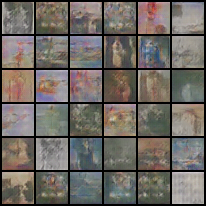

[DCGAN-v2] Epoch  25/100 | D=0.2016 | G=5.6446 | D(real)=0.8979 | D(fake)=0.0112
[DCGAN-v2] Epoch  26/100 | D=0.1944 | G=5.8935 | D(real)=0.9013 | D(fake)=0.0087
[DCGAN-v2] Epoch  27/100 | D=0.1953 | G=5.9021 | D(real)=0.9003 | D(fake)=0.0089
[DCGAN-v2] Epoch  28/100 | D=0.1984 | G=5.8939 | D(real)=0.8979 | D(fake)=0.0094
[DCGAN-v2] Epoch  29/100 | D=0.1964 | G=5.9857 | D(real)=0.9000 | D(fake)=0.0080
[DCGAN-v2] Epoch  30/100 | D=0.1966 | G=5.9255 | D(real)=0.8985 | D(fake)=0.0093
[DCGAN-v2] Epoch  31/100 | D=0.1889 | G=6.1467 | D(real)=0.9014 | D(fake)=0.0067
[DCGAN-v2] Epoch  32/100 | D=0.1931 | G=6.1049 | D(real)=0.8998 | D(fake)=0.0101
[DCGAN-v2] Epoch  33/100 | D=0.1966 | G=6.1233 | D(real)=0.8966 | D(fake)=0.0098
[DCGAN-v2] Epoch  34/100 | D=0.1922 | G=6.2824 | D(real)=0.8968 | D(fake)=0.0086
[DCGAN-v2] Epoch  35/100 | D=0.1831 | G=6.5361 | D(real)=0.9021 | D(fake)=0.0047
[DCGAN-v2] Epoch  36/100 | D=0.1906 | G=6.5162 | D(real)=0.8992 | D(fake)=0.0074
[DCGAN-v2] Epoch  37/100 | D

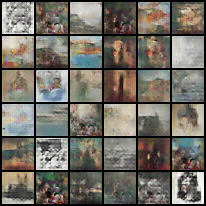

[DCGAN-v2] Epoch  50/100 | D=0.1815 | G=6.8225 | D(real)=0.8984 | D(fake)=0.0048
[DCGAN-v2] Epoch  51/100 | D=0.1728 | G=7.2071 | D(real)=0.9012 | D(fake)=0.0029
[DCGAN-v2] Epoch  52/100 | D=0.1735 | G=7.3716 | D(real)=0.9011 | D(fake)=0.0037
[DCGAN-v2] Epoch  53/100 | D=0.1857 | G=6.8780 | D(real)=0.8964 | D(fake)=0.0051
[DCGAN-v2] Epoch  54/100 | D=0.1718 | G=7.2173 | D(real)=0.9012 | D(fake)=0.0030
[DCGAN-v2] Epoch  55/100 | D=0.1735 | G=7.4829 | D(real)=0.9012 | D(fake)=0.0027
[DCGAN-v2] Epoch  56/100 | D=0.1705 | G=7.7518 | D(real)=0.9014 | D(fake)=0.0019
[DCGAN-v2] Epoch  57/100 | D=0.1722 | G=7.8758 | D(real)=0.9000 | D(fake)=0.0017
[DCGAN-v2] Epoch  58/100 | D=0.1727 | G=7.5400 | D(real)=0.8994 | D(fake)=0.0026
[DCGAN-v2] Epoch  59/100 | D=0.1730 | G=7.3194 | D(real)=0.9020 | D(fake)=0.0024
[DCGAN-v2] Epoch  60/100 | D=0.1749 | G=7.3560 | D(real)=0.9009 | D(fake)=0.0028
[DCGAN-v2] Epoch  61/100 | D=0.1703 | G=7.4895 | D(real)=0.9012 | D(fake)=0.0021
[DCGAN-v2] Epoch  62/100 | D

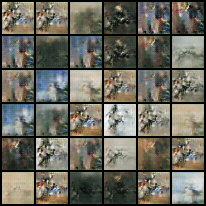

[DCGAN-v2] Epoch  75/100 | D=0.1693 | G=7.7621 | D(real)=0.9027 | D(fake)=0.0016
[DCGAN-v2] Epoch  76/100 | D=0.1703 | G=7.8597 | D(real)=0.9013 | D(fake)=0.0017
[DCGAN-v2] Epoch  77/100 | D=0.1691 | G=7.7847 | D(real)=0.9024 | D(fake)=0.0018
[DCGAN-v2] Epoch  78/100 | D=0.1683 | G=8.1179 | D(real)=0.9020 | D(fake)=0.0017
[DCGAN-v2] Epoch  79/100 | D=0.1688 | G=8.4109 | D(real)=0.9020 | D(fake)=0.0012
[DCGAN-v2] Epoch  80/100 | D=0.1679 | G=8.0704 | D(real)=0.9024 | D(fake)=0.0014
[DCGAN-v2] Epoch  81/100 | D=0.1682 | G=8.1494 | D(real)=0.9018 | D(fake)=0.0012
[DCGAN-v2] Epoch  82/100 | D=0.1671 | G=8.2937 | D(real)=0.9029 | D(fake)=0.0012
[DCGAN-v2] Epoch  83/100 | D=0.1706 | G=7.6759 | D(real)=0.9004 | D(fake)=0.0025
[DCGAN-v2] Epoch  84/100 | D=0.1698 | G=7.3635 | D(real)=0.9022 | D(fake)=0.0021
[DCGAN-v2] Epoch  85/100 | D=0.1730 | G=7.5983 | D(real)=0.8993 | D(fake)=0.0030
[DCGAN-v2] Epoch  86/100 | D=0.1714 | G=7.1365 | D(real)=0.9010 | D(fake)=0.0029
[DCGAN-v2] Epoch  87/100 | D

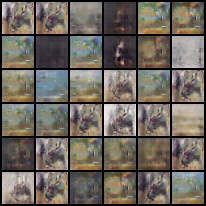

[DCGAN-v2] Epoch 100/100 | D=0.1668 | G=7.8991 | D(real)=0.9029 | D(fake)=0.0013

Finished dcgan_v2_ep100_seed42 | time=60.8 min | G_loss=7.8991


In [16]:
import os, csv, json, gc, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image, make_grid
from IPython.display import display as ipy_display, Image as IPyImage

# ── Config ────────────────────────────────────────────────────────────────────
latent_dim    = 256
img_channels  = 3
img_size      = IMAGE_SIZE
hidden_dims   = [32, 64, 128, 256]
learning_rate = 2e-4
beta1, beta2  = 0.5, 0.999
num_epochs    = 100
n_critic      = 2      # train D n_critic times per G update
real_label    = 0.9    # label smoothing — prevents D from becoming overconfident
fake_label    = 0.0
seed          = 42

base_runs_dir    = RUNS_DIR
base_runs_dir.mkdir(parents=True, exist_ok=True)
summary_csv_path = base_runs_dir / "summary_dcgan_v2.csv"
device           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Train size: {len(train_loader_full.dataset):,}")
print(f"Changes vs v1:  n_critic={n_critic}, label_smoothing={real_label}, no D grad-clip")


def _save_grid(G, noise, save_path, nrow=6):
    G.eval()
    with torch.no_grad():
        fake = ((G(noise).detach().cpu() + 1.0) / 2.0).clamp(0, 1)
    save_image(make_grid(fake, nrow=nrow, padding=2), save_path)
    G.train()


def train_dcgan_v2():
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    run_name = f"dcgan_v2_ep{num_epochs}_seed{seed}"
    run_dir  = base_runs_dir / run_name; run_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir    = run_dir / "checkpoints"; ckpt_dir.mkdir(exist_ok=True)
    samples_dir = run_dir / "samples";     samples_dir.mkdir(exist_ok=True)
    metrics_csv = run_dir / "metrics.csv"
    final_g_path = run_dir / "final_generator.pt"
    final_d_path = run_dir / "final_discriminator.pt"

    config = {
        "run_name": run_name, "model_family": "dcgan_v2", "seed": seed,
        "latent_dim": latent_dim, "img_channels": img_channels,
        "img_size": img_size, "hidden_dims": hidden_dims,
        "learning_rate": learning_rate, "beta1": beta1, "beta2": beta2,
        "num_epochs": num_epochs, "n_critic": n_critic,
        "real_label": real_label, "label_smoothing": True,
        "grad_clip_G": 1.0, "grad_clip_D": None,
        "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size,
    }
    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2)

    G = Generator(latent_dim=latent_dim, img_channels=img_channels,
                  img_size=img_size, hidden_dims=hidden_dims).to(device)
    D = Discriminator(img_channels=img_channels, hidden_dims=hidden_dims).to(device)
    G.apply(dcgan_weights_init); D.apply(dcgan_weights_init)

    criterion   = nn.BCEWithLogitsLoss()
    optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(beta1, beta2))
    optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(beta1, beta2))
    fixed_noise = torch.randn(36, latent_dim, device=device)

    fieldnames = ["epoch", "d_loss", "g_loss", "d_real_mean", "d_fake_mean"]
    with open(metrics_csv, "w", newline="") as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()

    print("\n" + "=" * 100)
    print(f"Starting: {run_name}  |  n_critic={n_critic}  |  label_smoothing={real_label}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        G.train(); D.train()
        d_sum = g_sum = dr_sum = df_sum = 0.0
        nb_batches = 0

        for batch in train_loader_full:
            real_imgs = batch[0].to(device, non_blocking=True)
            bs = real_imgs.size(0)
            real_t = torch.full((bs,), real_label, device=device)  # label smoothing
            fake_t = torch.full((bs,), fake_label, device=device)

            # ── D step × n_critic ────────────────────────────────────────────
            for _ in range(n_critic):
                z = torch.randn(bs, latent_dim, device=device)
                fi = G(z).detach()
                optimizer_D.zero_grad()
                d_real = criterion(D(real_imgs), real_t)
                d_fake = criterion(D(fi), fake_t)
                d_loss = (d_real + d_fake) * 0.5
                d_loss.backward()
                # No gradient clipping on D — lets it recover from G attacks
                optimizer_D.step()

            # ── G step × 1 ───────────────────────────────────────────────────
            z = torch.randn(bs, latent_dim, device=device)
            fi = G(z)
            optimizer_G.zero_grad()
            flg = D(fi)
            g_loss = criterion(flg, torch.ones(bs, device=device))  # G wants D(fake)=1
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()

            d_sum  += d_loss.item(); g_sum  += g_loss.item()
            dr_sum += torch.sigmoid(D(real_imgs).detach()).mean().item()
            df_sum += torch.sigmoid(flg.detach()).mean().item()
            nb_batches += 1

        d_e = d_sum/nb_batches; g_e = g_sum/nb_batches
        dr_e = dr_sum/nb_batches; df_e = df_sum/nb_batches

        with open(metrics_csv, "a", newline="") as f:
            csv.DictWriter(f, fieldnames=fieldnames).writerow({
                "epoch": epoch+1, "d_loss": d_e, "g_loss": g_e,
                "d_real_mean": dr_e, "d_fake_mean": df_e,
            })

        if (epoch + 1) % 25 == 0:
            sp = samples_dir / f"epoch_{epoch+1:03d}.png"
            _save_grid(G, fixed_noise, sp)
            print(f"Samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sp), width=500))

        print(f"[DCGAN-v2] Epoch {epoch+1:>3}/{num_epochs} | "
              f"D={d_e:.4f} | G={g_e:.4f} | D(real)={dr_e:.4f} | D(fake)={df_e:.4f}")

    total_time = time.time() - start_time

    torch.save({"epoch": num_epochs, "model_state_dict": G.state_dict(),
                "final_g_loss": g_e, "config": config}, final_g_path)
    torch.save({"epoch": num_epochs, "model_state_dict": D.state_dict(),
                "config": config}, final_d_path)

    summary_row = {
        "run_name": run_name, "latent_dim": latent_dim, "num_epochs": num_epochs,
        "final_g_loss": g_e, "train_size": len(train_loader_full.dataset),
        "batch_size": train_loader_full.batch_size, "learning_rate": learning_rate,
        "n_critic": n_critic, "real_label": real_label,
        "final_g_path": str(final_g_path), "final_d_path": str(final_d_path),
        "time_sec": total_time, "status": "ok",
    }
    print(f"\nFinished {run_name} | time={total_time/60:.1f} min | G_loss={g_e:.4f}")
    return summary_row


summary_fieldnames = [
    "run_name", "latent_dim", "num_epochs", "final_g_loss", "train_size",
    "batch_size", "learning_rate", "n_critic", "real_label",
    "final_g_path", "final_d_path", "time_sec", "status",
]
with open(summary_csv_path, "w", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writeheader()

try:
    result = train_dcgan_v2()
except RuntimeError as e:
    result = {k: None for k in summary_fieldnames}
    result.update({"run_name": f"dcgan_v2_ep{num_epochs}_seed{seed}",
                   "status": f"error: {e}"})
    print(f"Training failed: {e}")

with open(summary_csv_path, "a", newline="") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writerow(result)

gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


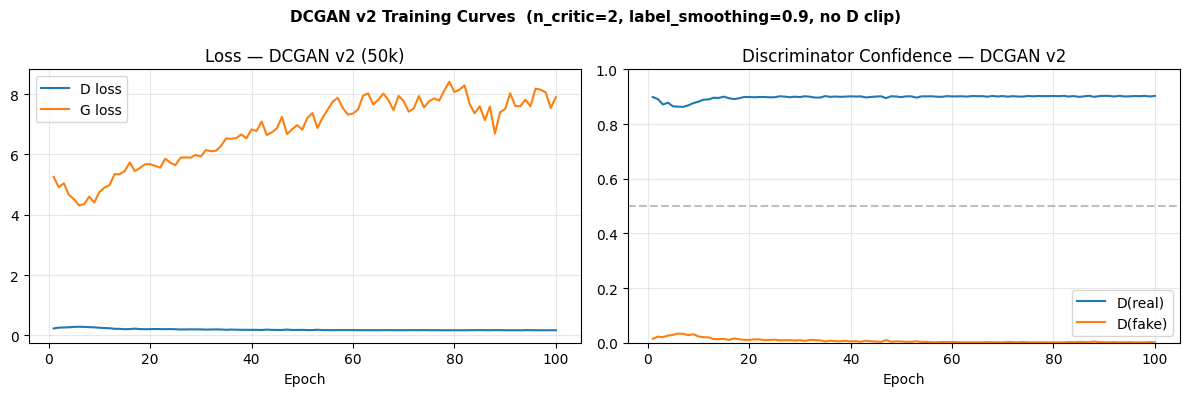

In [17]:
import csv, matplotlib.pyplot as plt
from pathlib import Path

_base    = RUNS_DIR
_metrics = _base / "dcgan_v2_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, d_loss, g_loss, d_real, d_fake = [], [], [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            d_loss.append(float(row["d_loss"]));      g_loss.append(float(row["g_loss"]))
            d_real.append(float(row["d_real_mean"])); d_fake.append(float(row["d_fake_mean"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ep, d_loss, label="D loss"); axes[0].plot(ep, g_loss, label="G loss")
    axes[0].set_title("Loss — DCGAN v2 (50k)"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, d_real, label="D(real)"); axes[1].plot(ep, d_fake, label="D(fake)")
    axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    axes[1].set_title("Discriminator Confidence — DCGAN v2")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.suptitle("DCGAN v2 Training Curves  (n_critic=2, label_smoothing=0.9, no D clip)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    _fig_dir = _base / "figures"; _fig_dir.mkdir(exist_ok=True)
    plt.savefig(_fig_dir / "dcgan_v2_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Inference (36 samples): 0.002s | 0.1 ms/image


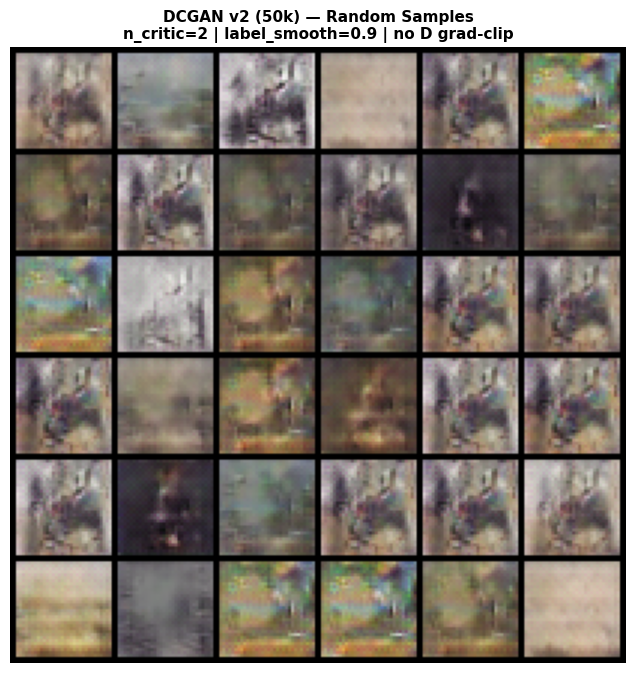

In [18]:
import torch, matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path
import time as _time_mod

_base     = RUNS_DIR
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = _base / "dcgan_v2_ep100_seed42" / "final_generator.pt"

if not ckpt_path.exists():
    print(f"Checkpoint not found: {ckpt_path}")
else:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg  = ckpt["config"]
    G = Generator(latent_dim=cfg["latent_dim"], img_channels=cfg["img_channels"],
                  img_size=cfg["img_size"], hidden_dims=cfg["hidden_dims"]).to(device)
    G.load_state_dict(ckpt["model_state_dict"])
    G.eval()

    # warmup
    with torch.no_grad(): _ = G(torch.randn(4, cfg["latent_dim"], device=device))
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        z = torch.randn(36, cfg["latent_dim"], device=device)
        samples = G(z)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t = _time_mod.time() - _t0
    print(f"Inference (36 samples): {_t:.3f}s | {_t/36*1000:.1f} ms/image")

    imgs = ((samples.detach().cpu() + 1.0) / 2.0).clamp(0, 1)
    grid = make_grid(imgs, nrow=6, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title("DCGAN v2 (50k) — Random Samples\n"
              "n_critic=2 | label_smooth=0.9 | no D grad-clip",
              fontsize=11, fontweight="bold")
    _fig_dir = _base / "figures"; _fig_dir.mkdir(exist_ok=True)
    plt.savefig(_fig_dir / "dcgan_v2_samples.png", dpi=150, bbox_inches="tight")
    plt.show()


In [19]:
# ── DCGAN v2 — FID/KID ───────────────────────────────────────────
import torch
from pathlib import Path

_base     = RUNS_DIR
ckpt_path = _base / "dcgan_v2_ep100_seed42" / "final_generator.pt"

if not ckpt_path.exists():
    print(f"Checkpoint not found: {ckpt_path}")
else:
    _ckpt  = torch.load(ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Generator(latent_dim=_cfg["latent_dim"], img_channels=_cfg["img_channels"],
                       img_size=_cfg["img_size"], hidden_dims=_cfg["hidden_dims"]).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="gan",
        latent_dim=_cfg["latent_dim"], img_channels=_cfg["img_channels"],
        img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["dcgan_v2"] = _res
    _save_results(_all)
    _print_results({"dcgan_v2": _res})

    # Comparison
    print("\n── DCGAN v1 vs v2 ───────────────────────────────────────────")
    print(f"{'Config':<30} {'FID':>8} {'FID±':>7} {'KID×10³':>10}")
    print("-" * 58)
    for key, label in [("dcgan_full", "DCGAN v1 (baseline)"),
                       ("dcgan_v2",   "DCGAN v2 (n_critic=2, smooth)")]:
        r = _all.get(key, {})
        if r:
            print(f"{label:<30} {r['fid_mean']:>8.2f} {r['fid_std']:>7.2f} "
                  f"{r['kid_mean']*1e3:>10.2f}")


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [gan] Rep 1/10 seed=0 | FID=219.41 | KID=149.4857±8.5825 (×10⁻³)


KeyboardInterrupt: 